<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[109 137 325 517 146 163  23  99 155 470]
[0.55590925 1.03895626 1.07887494 1.11747251 1.14116669 1.21485609
 1.25125685 1.26537556 1.26929893 1.27611243]
Radius (r): 1.2761
Volume (V): 5.1160
Estimated density p(x): 0.003258


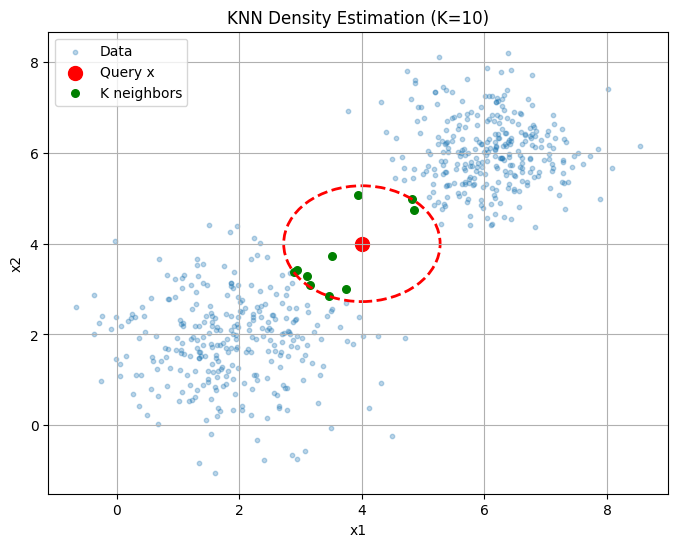

p(C0|x) = 0.7
p(C1|x) = 0.3


In [44]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic 2D data (instead of sklearn dataset)
# (You can later replace this with real data)
# np.random.seed(0)

''' Two clusters → helps visualization here we produce random data 300 quantity each, by default it is N(0,1)
first cluster multiply 1 variance at position (2,2)
second cluster multiply 0.8 variance at position (6,6)
'''
cluster1 = np.random.randn(300, 2) * 1 + np.array([2, 2])
cluster2 = np.random.randn(300, 2) * 0.8 + np.array([6, 6])

# vertically align two clusters
X = np.vstack([cluster1, cluster2])
N = X.shape[0]

# 2. Choose query point at (4,4)
x_query = np.array([4, 4])

# 3. Set K
K = 10

# 4. Compute Euclidean distances manually
diff = X - x_query              # shape (N, 2)
distances = np.sqrt(np.sum(diff**2, axis=1))

# 5. Sort distances and get K nearest
sorted_indices = np.argsort(distances)
K_indices = sorted_indices[:K]
print(K_indices)
K_distances = distances[K_indices]
print(K_distances)
# Radius = distance to K-th neighbor
radius = K_distances[-1]

# 6. Compute volume (2D circle)
V = np.pi * radius**2

# 7. Density estimate (PRML eq)
density = K / (N * V)

print(f"Radius (r): {radius:.4f}")
print(f"Volume (V): {V:.4f}")
print(f"Estimated density p(x): {density:.6f}")

# 8. Visualization
plt.figure(figsize=(8, 6))

# All data
plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.3, label="Data")

# Query point
plt.scatter(x_query[0], x_query[1], color='red', s=100, label="Query x")

# K neighbors
neighbors = X[K_indices]
plt.scatter(neighbors[:, 0], neighbors[:, 1], color='green', s=30, label="K neighbors")

# Draw circle
circle = plt.Circle(x_query, radius, color='red', fill=False, linestyle='--', linewidth=2)
plt.gca().add_patch(circle)

plt.title(f"KNN Density Estimation (K={K})")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Example labels
y = np.array([0]*300 + [1]*300)

# Get neighbor labels
neighbor_labels = y[K_indices]

# Count class occurrences
K0 = np.sum(neighbor_labels == 0)
K1 = np.sum(neighbor_labels == 1)

print("p(C0|x) =", K0 / K)
print("p(C1|x) =", K1 / K)

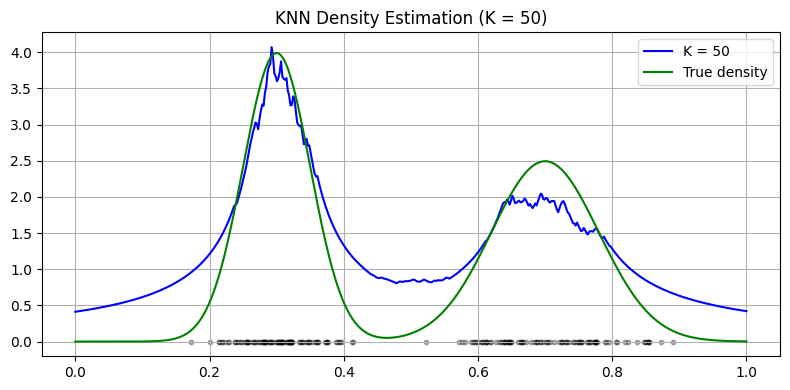

In [43]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1. Generate 1D multimodal data (like PRML example)
N = 200
data1 = np.random.normal(loc=0.3, scale=0.05, size=N//2)
data2 = np.random.normal(loc=0.7, scale=0.08, size=N//2)
X = np.hstack([data1, data2])

# 2. Points where we estimate density
x_grid = np.linspace(0, 1, 500)

# 3. K values (like PRML figure)
K = 50

# 4. Function to compute KNN density (1D)
def knn_density_1d(x_grid, X, K):
    N = len(X)
    densities = []

    for x in x_grid:
        # Compute distances
        distances = np.abs(X - x)

        # Sort distances
        sorted_distances = np.sort(distances)


        # Distance to K-th neighbor
        r = sorted_distances[K-1]

        # Volume in 1D = length of interval = 2r
        V = 2 * r

        # Avoid division by zero
        if V == 0:
            density = 0
        else:
            density = K / (N * V)

        densities.append(density)


    return np.array(densities)

# 5. Plot results
plt.figure(figsize=(8,4))

density = knn_density_1d(x_grid, X, K)

plt.plot(x_grid, density, 'b', label=f"K = {K}")

# True distribution (for reference)
true_pdf = (
    0.5 * (1/(0.05*np.sqrt(2*np.pi))) * np.exp(-(x_grid-0.3)**2/(2*0.05**2)) +
    0.5 * (1/(0.08*np.sqrt(2*np.pi))) * np.exp(-(x_grid-0.7)**2/(2*0.08**2))
)
plt.plot(x_grid, true_pdf, 'g', label="True density")

# Show data points
plt.scatter(X, np.zeros_like(X), color='black', s=10, alpha=0.3)

plt.title(f"KNN Density Estimation (K = {K})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

